In [1]:
# ===== 라이브러리 =====
import os, glob
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 50)

# ===== 경로 =====
RAW  = '../data/raw/epoch_data'
PROC = '../data/processed'

# ===== 기준일 =====
TRAIN_DATE = '2026-08-11'
HOLD_DATE  = '2026-08-25'
D          = '2026-09-01'     # 본선 테스트

CUT_HOURS = 121    # 기준일로부터 5일(120h) 지난 영상의 view_5d만 사용

# ===== DuckDB 연결 =====
con = duckdb.connect()
con.sql("SET memory_limit = '4GB'")
for p in sorted(glob.glob(f'{RAW}/*.csv')):
    name = os.path.splitext(os.path.basename(p))[0]
    con.sql(f"""CREATE OR REPLACE VIEW {name} AS
                SELECT * FROM read_csv('{p}', header=true, auto_detect=true)""")
con.sql(f"CREATE OR REPLACE VIEW video_snapshots AS SELECT * FROM '{PROC}/video_snapshots.parquet'")

# ===== train/holdout 분리 (02번에서 저장해둔 것) =====
train   = pd.read_csv(f'{PROC}/split_train.csv')
holdout = pd.read_csv(f'{PROC}/split_holdout.csv')
print('준비 완료:', train.shape, holdout.shape)

준비 완료: (601, 4) (666, 4)


In [2]:
# make_features(D) — 02번 EDA를 함수로 정리 

def make_features(Dref):
    """기준일 Dref 시점에 알 수 있는 정보로 채널별 피처를 만든다.
       08-11 / 08-25 / 09-01 어디에 넣어도 똑같이 동작해야 함."""

    raw = con.sql(f"""
    WITH v5 AS (            -- 롱폼 view_5d 기반 성적 (기준일 시점 기준으로만 사용)
        SELECT channel_id,
               COUNT(*)                                       AS n_long_5d,
               MEDIAN(view_5d)                                AS past_med,
               MEDIAN(view_5d) FILTER (
                   WHERE published_at >= TIMESTAMP '{Dref}' - INTERVAL 14 DAY
               )                                              AS recent14_med,
               MEDIAN(like_5d / NULLIF(view_5d, 0))           AS like_rate
        FROM video_5d_views
        WHERE is_shorts = 0 AND view_5d IS NOT NULL
          AND published_at < TIMESTAMP '{Dref}' - INTERVAL {CUT_HOURS} HOUR
        GROUP BY 1
    ),
    up AS (                 -- 업로드 기록 (업로드 "시각"만 쓰므로 기준일 직전까지 전부 알 수 있음)
        SELECT channel_id,
               COUNT(*) FILTER (
                   WHERE is_shorts = 0 AND published_at >= TIMESTAMP '{Dref}' - INTERVAL 14 DAY
               )                                                                AS n_long_14,
               COUNT(*) FILTER (
                   WHERE is_shorts = 1 AND published_at >= TIMESTAMP '{Dref}' - INTERVAL 14 DAY
               )                                                                AS n_short_14,
               DATE_DIFF('hour', MAX(published_at) FILTER (WHERE is_shorts = 0), TIMESTAMP '{Dref}') / 24.0
                                                                                 AS days_since_long
        FROM videos
        WHERE published_at < TIMESTAMP '{Dref}'
        GROUP BY 1
    )
    SELECT * FROM v5 LEFT JOIN up USING (channel_id)
    """).df()

    # ===== recent_status: 결측의 의미를 구분 (EDA에서 확인한 핵심) =====
    has_upload  = raw.n_long_14 > 0
    has_measure = raw.recent14_med.notna()
    raw['recent_status'] = np.select(
        [~has_upload, has_upload & ~has_measure, has_measure],
        ['안_올림', '측정_전', '측정_가능'],
        default='알수없음'
    )

    # momentum14는 측정_가능일 때만 계산 (안_올림/측정_전은 결측으로 남김 → 모델에서 범주로 처리)
    raw['momentum14'] = np.where(
        raw['recent_status'] == '측정_가능',
        np.log1p(raw.recent14_med) - np.log1p(raw.past_med),
        np.nan
    )
    raw['short_ratio'] = raw.n_short_14 / (raw.n_short_14 + raw.n_long_14).replace(0, np.nan)

    # ===== past_med가 치우쳐 있으므로 log 변환 버전도 같이 제공 =====
    raw['log_past_med'] = np.log1p(raw.past_med)

    return raw

# train 기준일로 테스트
f = make_features(TRAIN_DATE)
print(f.shape)
f.head()

(818, 12)


,channel_id,n_long_5d,past_med,recent14_med,like_rate,n_long_14,n_short_14,days_since_long,recent_status,momentum14,short_ratio,log_past_med
0,UC1Ns07Rw0lQK-KuaPHfRRTw,31,18.0,40.0,0.000000,17,0,0.416667,측정_가능,0.769133,0.000000,2.944439
1,UC1aBdmKvC6yAiq4xgPLOzKA,5,19799.0,21945.5,0.015087,3,8,3.791667,측정_가능,0.102926,0.727273,9.893437
2,UC2U8C7lmbQpfBeAW8fTP_jg,14,22463.0,20879.0,0.022128,9,1,0.750000,측정_가능,-0.073122,0.100000,10.019669
3,UC8CZL4cvFiKwKKDNCuM2lTA,25,8670.0,10708.0,0.007949,11,6,0.083333,측정_가능,0.211100,0.352941,9.067739
4,UC8CIM3d3zDYMk-3T5aAz0yw,23,444870.0,313211.0,0.025798,11,1,0.583333,측정_가능,-0.350904,0.083333,13.005540


In [3]:
# train(08-11), holdout(08-25) 각각에 맞는 기준일로 피처 생성 후 합치기
train_f   = train.merge(make_features(TRAIN_DATE), on='channel_id', how='left')
holdout_f = holdout.merge(make_features(HOLD_DATE), on='channel_id', how='left')

print('train  :', train_f.shape, '| 결측 있는 행:', train_f.past_med.isna().sum())
print('holdout:', holdout_f.shape, '| 결측 있는 행:', holdout_f.past_med.isna().sum())

train  : (601, 15) | 결측 있는 행: 0
holdout: (666, 15) | 결측 있는 행: 0


In [4]:
# 전처리 (train에만 fit)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ===== 쓸 피처 목록 =====
NUM_COLS = ['log_past_med', 'n_long_5d', 'like_rate', 'n_long_14',
            'n_short_14', 'short_ratio', 'days_since_long', 'momentum14']
CAT_COLS = ['recent_status']   # 안_올림 / 측정_전 / 측정_가능

# 수치형: 결측은 중앙값으로 채우고 표준화 (momentum14 결측 = 측정_전/안_올림이라 recent_status가 이미 그 정보를 담고 있음)
num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])

# 범주형: 원-핫 인코딩
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocess = ColumnTransformer([
    ('num', num_pipe, NUM_COLS),
    ('cat', cat_pipe, CAT_COLS),
])

# ===== train에만 fit, train/holdout 둘 다 transform =====
X_train = preprocess.fit_transform(train_f)
y_train = train_f['target']

X_hold = preprocess.transform(holdout_f)
y_hold = holdout_f['target']

print(X_train.shape, X_hold.shape)

(601, 11) (666, 11)


In [7]:
# 베이스라인 로지스틱 회귀

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

model = LogisticRegression(max_iter=1000, class_weight='balanced')  # 양성 20%라 불균형 보정
model.fit(X_train, y_train)

# ===== holdout(08-25)으로 평가 =====
pred_hold = model.predict_proba(X_hold)[:, 1]

pr_auc  = average_precision_score(y_hold, pred_hold)
roc_auc = roc_auc_score(y_hold, pred_hold)

print(f'PR-AUC : {pr_auc:.3f}  (무작위 기준 약 0.20)')
print(f'ROC-AUC: {roc_auc:.3f}  (무작위 기준 0.50)')

PR-AUC : 0.344  (무작위 기준 약 0.20)
ROC-AUC: 0.735  (무작위 기준 0.50)


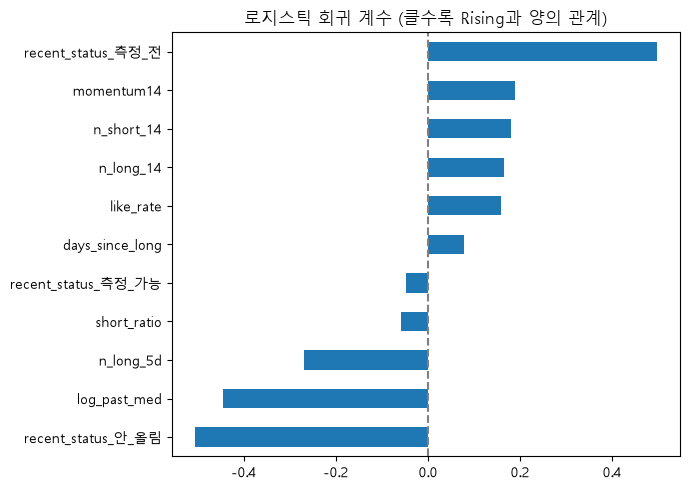

In [8]:
# 어떤 피처가 중요한가

# 원-핫 인코딩 후 컬럼 이름 가져오기
feat_names = (NUM_COLS +
              list(preprocess.named_transformers_['cat']
                   .named_steps['onehot'].get_feature_names_out(CAT_COLS)))

coef = pd.Series(model.coef_[0], index=feat_names).sort_values()
coef.plot(kind='barh', figsize=(7, 5), title='로지스틱 회귀 계수 (클수록 Rising과 양의 관계)')
plt.axvline(0, c='gray', ls='--')
plt.tight_layout()
plt.show()

- PR-AUC 0.344, ROC-AUC 0.735 (무작위 기준 0.20 / 0.50)
- log_past_med 음수 → 과거 성적 낮을수록 Rising (EDA의 평균 회귀와 일치)
- recent_status_측정_전 영향력 가장 큼 → EDA에서 Rising 비율 0.333이었던 집단과 일치
- recent_status_안_올림 가장 큰 음수 → 최근에 안 올리면 Rising 가능성 낮음
- momentum14는 EDA에서 노이즈로 봤는데 계수는 꽤 크게 나옴 → 재확인 필요

=> 이 점수(PR-AUC 0.344)를 베이스라인으로, LightGBM과 추가 비교 예정

In [9]:
BEST_MODEL = model   # 지금은 로지스틱 회귀 베이스라인
FILE = '../submissions/submit_01_baseline_logreg.csv'

# 09-01 기준 피처 생성 → 전처리(이미 fit된 것 재사용) → 예측
f_D = make_features(D)
sample = pd.read_csv(f'{RAW}/sample_submission.csv')
sample['channel_id'] = sample['row_id'].str.rsplit('_', n=1).str[0]

sub = sample.drop(columns='prediction').merge(f_D, on='channel_id', how='left')

# train에 없던 상황(측정_가능 외 범주 없음 등)이 있을 수 있으니 결측 확인
print('09-01 기준 결측 있는 행:', sub[NUM_COLS + CAT_COLS].isna().any(axis=1).sum())

X_sub = preprocess.transform(sub)                 # train에서 fit한 그대로 적용
sub['prediction'] = BEST_MODEL.predict_proba(X_sub)[:, 1]
sub = sub[['row_id', 'prediction']]

# ===== 제출 전 검사 (제출 가이드 3절) =====
assert len(sub) == len(sample) == 694
assert set(sub.row_id) == set(sample.row_id)
assert sub.prediction.notna().all()
assert sub.prediction.between(0, 1).all()

sub.to_csv(FILE, index=False)
print('저장 완료:', FILE)
sub.head()

09-01 기준 결측 있는 행: 98
저장 완료: ../submissions/submit_01_baseline_logreg.csv


,row_id,prediction
0,UCl-VnCUwSxDr5zPu-YlDUYw_2026-09-01,0.489063
1,UCnkytUgy0CtWd06up9CjNxg_2026-09-01,0.202981
2,UCpI-AhCT02iQRGLC2ZcY0Jw_2026-09-01,0.155418
3,UC9otskL_kd-0CDib_5Lj-mQ_2026-09-01,0.482701
4,UCSzHok6X5qXEO7cjvVnE62g_2026-09-01,0.142792


In [10]:
# 결측 98개 원인 대략 확인
missing = sub_before_fillna = f_D[f_D.past_med.isna()] if 'f_D' in dir() else None
check = sample.merge(con.sql("SELECT channel_id, created_at FROM channels").df(), on='channel_id', how='left')
miss_ch = set(sample.channel_id) - set(f_D.channel_id)
ch_info = con.sql(f"SELECT channel_id, created_at FROM channels WHERE channel_id IN {tuple(miss_ch)}").df()
print('채널 개설일 분포:')
print(pd.to_datetime(ch_info.created_at).dt.date.describe())

채널 개설일 분포:
count              1
unique             1
top       2023-06-05
freq               1
Name: created_at, dtype: object


In [11]:
# miss_ch 자체가 몇 개인지부터 확인
print('결측 채널 수:', len(miss_ch))

# tuple 함정 피해서 다시 쿼리 (리스트를 직접 바인딩)
ch_info = con.sql("""
    SELECT channel_id, created_at
    FROM channels
    WHERE channel_id IN (SELECT UNNEST($1))
""", params=[list(miss_ch)]).df()

print(ch_info.shape)
print(pd.to_datetime(ch_info.created_at).dt.date.describe())

결측 채널 수: 1
(1, 2)
count              1
unique             1
top       2023-06-05
freq               1
Name: created_at, dtype: object


### 📝 기록: 연습 리더보드 1차 제출 (submit_01_baseline_logreg)
- 리더보드 점수 0.3438, 1위와 격차 -0.4189.
  holdout(08-25) 로컬 PR-AUC 0.344와 거의 일치.
- **알게 된 것:** 로컬 검증(08-11 학습 → 08-25 평가) 방식이 실제 09-01 테스트와
  잘 맞는다는 게 확인됨 → 모델/피처 비교는 로컬 검증으로도 어느정도 신뢰 가능함

-> LightGBM 등 모델 추가로 진행. 
  momentum14 재검토, 추가 피처(like_rate 외 영상 성과 지표), 트리 모델 비교.